# Report schematics

Generates static schematic figures for the report (no simulation, no
warmup/measurement protocol). Output goes to `../Report/images/` so
the LaTeX picks it up via `\includegraphics{images/...}` from
`Bakri/Report/main.tex`.

Each cell saves a single named PDF + PNG pair. PDF is what LaTeX
embeds (vector); PNG is for previewing in the notebook output area.

In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyBboxPatch

# Font sizes are tuned so that after LaTeX shrinks the figure with
# \includegraphics[width=\textwidth] (~0.52x for a 13in source on a
# 6.77in textwidth article), in-figure text matches or exceeds the
# 10pt body text of the report. font.size 20 -> ~10.4pt in PDF.
plt.rcParams.update({
    "figure.dpi":     120,
    "savefig.dpi":    200,
    "savefig.bbox":   "tight",
    "font.size":      20,
    "axes.titlesize": 22,
})

IMAGES_DIR = "../Report/images"
os.makedirs(IMAGES_DIR, exist_ok=True)


def save_fig(fig, name):
    fig.savefig(os.path.join(IMAGES_DIR, f"{name}.pdf"))
    fig.savefig(os.path.join(IMAGES_DIR, f"{name}.png"))
    print(f"saved {name}.pdf and {name}.png to {IMAGES_DIR}")

## scenarios_schematic — three studied geometries

Three side-by-side panels: (a) single-lane road with N evenly-spaced
lights, (b) two-lane road with mixed vehicle types and synchronised
lights, (c) perpendicular intersection of two single-lane roads with
one phased signal at the crossing.

Used in **Section 1 (Introduction)** to anchor the four research
questions in a visible geometry before the Background section.

In [2]:
ROAD = "#e8e8e8"
CAR  = "#3b6fb6"
TRUCK = "#b03a2e"
GREEN = "#2ca02c"
RED   = "#d62728"


def draw_road_h(ax, x0, x1, y_centre, n_lanes=1, lane_h=0.5):
    height = n_lanes * lane_h
    ax.add_patch(Rectangle((x0, y_centre - height / 2), x1 - x0, height,
                           facecolor=ROAD, edgecolor="black", linewidth=1.0))
    if n_lanes == 2:
        ax.plot([x0 + 0.2, x1 - 0.2], [y_centre, y_centre],
                color="white", linewidth=1.0,
                linestyle=(0, (4, 4)))


def draw_road_v(ax, y0, y1, x_centre, width=0.5):
    ax.add_patch(Rectangle((x_centre - width / 2, y0), width, y1 - y0,
                           facecolor=ROAD, edgecolor="black", linewidth=1.0))


def draw_car(ax, x, y, w=0.7, h=0.28, color=CAR):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle="round,pad=0.02,rounding_size=0.06",
                                facecolor=color, edgecolor="black",
                                linewidth=0.7))


def draw_truck(ax, x, y, w=1.3, h=0.32, color=TRUCK):
    draw_car(ax, x, y, w=w, h=h, color=color)


def draw_car_v(ax, x, y, w=0.28, h=0.7, color=CAR):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle="round,pad=0.02,rounding_size=0.06",
                                facecolor=color, edgecolor="black",
                                linewidth=0.7))


def draw_light(ax, x, y, color):
    ax.add_patch(Circle((x, y), 0.15, facecolor=color,
                        edgecolor="black", linewidth=0.8, zorder=5))

saved scenarios_schematic.pdf and scenarios_schematic.png to ../Report/images


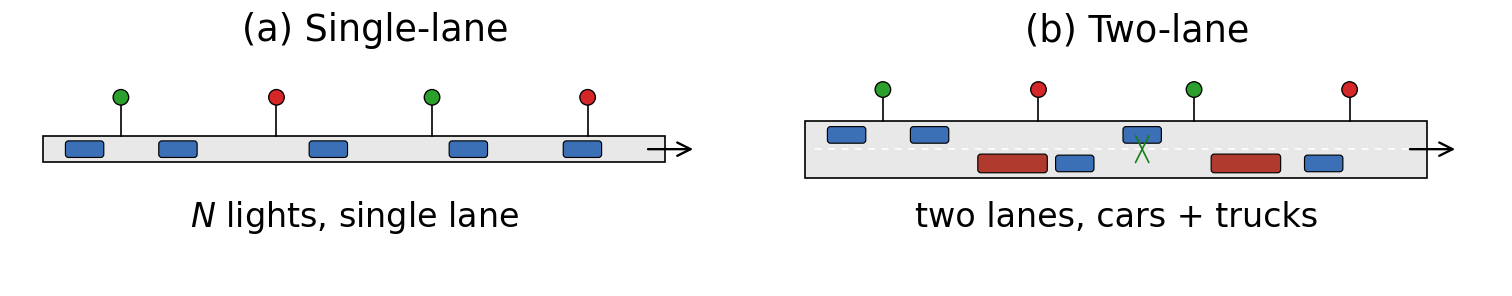

In [3]:
fig = plt.figure(figsize=(13, 4.0))
gs = fig.add_gridspec(1, 2)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
# ax_c = fig.add_subplot(gs[1, :])  # intersection panel deferred — flip `if False` below to `if True` and restore (2, 2) gridspec to bring back

L = 12.0
N_LIGHTS = 4

# - (a) single-lane -
ax = ax_a
draw_road_h(ax, 0, L, 0, n_lanes=1)
for cx in [0.8, 2.6, 5.5, 8.2, 10.4]:
    draw_car(ax, cx, 0)
for i in range(N_LIGHTS):
    lx = (i + 0.5) * L / N_LIGHTS
    ax.plot([lx, lx], [0.25, 0.85], color="black", linewidth=1.0)
    draw_light(ax, lx, 1.0, color=GREEN if i % 2 == 0 else RED)
ax.annotate("", xy=(L + 0.6, 0), xytext=(L - 0.4, 0),
            arrowprops=dict(arrowstyle="->", lw=1.4))
ax.text(L / 2, -1.5, "$N$ lights, single lane", ha="center")
ax.set_xlim(-0.6, L + 1.4)
ax.set_ylim(-2.6, 1.9)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("(a) Single-lane")

# - (b) two-lane mixed -
ax = ax_b
draw_road_h(ax, 0, L, 0, n_lanes=2, lane_h=0.55)
for (cx, lane_y) in [(0.8, 0.275), (2.4, 0.275), (5.2, -0.275),
                     (6.5, 0.275), (10.0, -0.275)]:
    draw_car(ax, cx, lane_y)
draw_truck(ax, 4.0, -0.275)
draw_truck(ax, 8.5, -0.275)
ax.annotate("", xy=(6.5, 0.10), xytext=(6.5, -0.10),
            arrowprops=dict(arrowstyle="<->", lw=1.0,
                            color="#1a7e1a"))
for i in range(N_LIGHTS):
    lx = (i + 0.5) * L / N_LIGHTS
    ax.plot([lx, lx], [0.55, 1.0], color="black", linewidth=1.0)
    draw_light(ax, lx, 1.15, color=GREEN if i % 2 == 0 else RED)
ax.annotate("", xy=(L + 0.6, 0), xytext=(L - 0.4, 0),
            arrowprops=dict(arrowstyle="->", lw=1.4))
ax.text(L / 2, -1.5, "two lanes, cars + trucks", ha="center")
ax.set_xlim(-0.6, L + 1.4)
ax.set_ylim(-2.6, 1.9)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("(b) Two-lane")

# - (c) perpendicular intersection (bottom row, full width) -
# Lights are spread further from the crossing (~1.5 data units each
# side) so the E-W and N-S labels above them don't overlap at body
# font size. Vertical cars sit at y=+/-1.0 to leave a clear gap for
# the south-bound arrow tail.
if False:  # intersection panel deferred — set to True to re-enable, and restore figsize=(13, 6.5), gridspec=(2, 2, height_ratios=[1.0, 1.6], hspace=0.3), and ax_c above
    ax = ax_c
    L_h = 14.0
    cx_int = L_h / 2
    cy_int = 0
    v_half = 1.8
    draw_road_h(ax, 0, L_h, cy_int, n_lanes=1)
    draw_road_v(ax, -v_half, v_half, cx_int)
    ax.add_patch(Rectangle((cx_int - 0.25, cy_int - 0.25), 0.5, 0.5,
                           facecolor=ROAD, edgecolor="none", zorder=3))
    for cx in [0.8, 2.4, 4.5, 9.0, 11.6, 13.0]:
        draw_car(ax, cx, 0)
    for cy in [-1.0, 1.0]:
        draw_car_v(ax, cx_int, cy)
    # E-W signal (currently green) right of the crossing
    ax.plot([cx_int + 1.5, cx_int + 1.5], [0.35, 0.95],
            color="black", linewidth=1.0)
    draw_light(ax, cx_int + 1.5, 1.10, color=GREEN)
    ax.text(cx_int + 1.5, 1.55, "E-W", ha="center")
    # N-S signal (currently red) left of the crossing
    ax.plot([cx_int - 1.5, cx_int - 1.5], [0.35, 0.95],
            color="black", linewidth=1.0)
    draw_light(ax, cx_int - 1.5, 1.10, color=RED)
    ax.text(cx_int - 1.5, 1.55, "N-S", ha="center")
    ax.annotate("", xy=(L_h + 0.6, 0), xytext=(L_h - 0.4, 0),
                arrowprops=dict(arrowstyle="->", lw=1.4))
    ax.annotate("", xy=(cx_int, -v_half - 0.7),
                xytext=(cx_int, -v_half + 0.1),
                arrowprops=dict(arrowstyle="->", lw=1.4))
    ax.text(cx_int, -v_half - 1.5, "one phased signal", ha="center")
    ax.set_xlim(-0.6, L_h + 1.4)
    ax.set_ylim(-v_half - 2.3, v_half + 1.0)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title("(c) Perpendicular intersection")

fig.tight_layout()
save_fig(fig, "scenarios_schematic")
plt.show()